# 12-01 TabPFN Validation Learning Curve

Dieses Notebook wertet vorhandene Legacy-Learning-Curve-Ergebnisse aus. Es legt keine finalen Hyperparameter fest.

Die verbindliche Modellwahl passiert in `12-02` mit `Top10` und `roc_auc` auf `X_valid`/`y_top10_valid`.


In [1]:
from pathlib import Path
from time import perf_counter
import json
import warnings

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "data" / "model_data").exists() and (candidate / "src" / "Notebooks").exists():
            return candidate
    raise FileNotFoundError("Projektwurzel mit data/model_data und src/Notebooks nicht gefunden.")

PROJECT_ROOT = find_project_root()
MODEL_DATA_DIR = PROJECT_ROOT / "data" / "model_data"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABPFN_DIR = PROCESSED_DIR / "tabpfn"
LEGACY_DIR = PROCESSED_DIR / "tabpfn_3_experiments"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"MODEL_DATA_DIR: {MODEL_DATA_DIR}")


PROJECT_ROOT: /Users/roberthendrich/GADA-Group3-Cycling-Stage-Prediction
MODEL_DATA_DIR: /Users/roberthendrich/GADA-Group3-Cycling-Stage-Prediction/data/model_data


In [2]:
RESULT_DIR = TABPFN_DIR / "01_validation_learning_curve"
RESULT_DIR.mkdir(parents=True, exist_ok=True)


def read_legacy_csv(name):
    path = LEGACY_DIR / name
    if not path.exists():
        warnings.warn(f"Legacy-Datei fehlt: {path}")
        return pd.DataFrame()
    return pd.read_csv(path)

summary = read_legacy_csv("tabpfn_client_lc_val2023_summary.csv")
stage_metrics = read_legacy_csv("tabpfn_client_lc_val2023_stage_metrics.csv")
usage_summary = read_legacy_csv("tabpfn_client_lc_val2023_usage_summary.csv")
sampling_plan = read_legacy_csv("tabpfn_client_lc_val2023_sampling_plan.csv")

print("summary", summary.shape)
print("stage_metrics", stage_metrics.shape)
print("usage_summary", usage_summary.shape)
print("sampling_plan", sampling_plan.shape)


summary (20, 21)
stage_metrics (1140, 14)
usage_summary (24, 19)
sampling_plan (4, 13)


## Legacy-Classifer-Zeilen isolieren

Nicht-Classifier-Zeilen werden nur als Kontext geladen und nicht als Kandidaten fuer `12-02` markiert.


In [3]:
if summary.empty:
    classifier_summary = pd.DataFrame()
else:
    assert "model_type" in summary.columns
    assert "target_rows" in summary.columns
    classifier_summary = summary[summary["model_type"].astype(str).str.contains("classifier", case=False, na=False)].copy()

classifier_summary.to_csv(RESULT_DIR / "legacy_learning_curve_classifier_summary.csv", index=False)
classifier_summary.head(20)


,rows,n_stages,spearman_global,ndcg_at_5,ndcg_at_10,ndcg_at_20,top_1_accuracy,top_5_accuracy,top_10_accuracy,top_20_accuracy,mean_stage_spearman,run_label,model_type,score_name,target,target_rows,actual_train_rows,seed,n_estimators,model_path,balance_probabilities
0,8897,57,0.310402,0.391817,0.399167,0.431884,0.175439,0.368421,0.491228,0.578947,0.304621,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,expected_value,target_ordinal,25000,25093,42,4,auto,True
1,8897,57,0.309019,0.393532,0.405194,0.436275,0.210526,0.368421,0.491228,0.561404,0.303848,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top10_probability,target_ordinal,25000,25093,42,4,auto,True
2,8897,57,0.315048,0.389547,0.400668,0.439465,0.175439,0.315789,0.491228,0.614035,0.308237,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top20_probability,target_ordinal,25000,25093,42,4,auto,True
3,8897,57,0.297751,0.385443,0.377621,0.418448,0.175439,0.350877,0.438596,0.561404,0.294285,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top5_probability,target_ordinal,25000,25093,42,4,auto,True
4,8897,57,0.297541,0.382235,0.385198,0.420833,0.140351,0.368421,0.491228,0.578947,0.294577,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,expected_value,target_ordinal,50000,50007,42,4,auto,True
5,8897,57,0.296142,0.378754,0.391211,0.419700,0.157895,0.333333,0.526316,0.578947,0.293347,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top10_probability,target_ordinal,50000,50007,42,4,auto,True
6,8897,57,0.303196,0.367225,0.386166,0.416073,0.122807,0.280702,0.491228,0.596491,0.298984,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top20_probability,target_ordinal,50000,50007,42,4,auto,True
7,8897,57,0.280927,0.360969,0.364068,0.402385,0.122807,0.350877,0.438596,0.578947,0.281939,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top5_probability,target_ordinal,50000,50007,42,4,auto,True
8,8897,57,0.305263,0.384194,0.385371,0.429591,0.140351,0.368421,0.491228,0.578947,0.303959,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,expected_value,target_ordinal,75000,75030,42,4,auto,True
9,8897,57,0.304678,0.399179,0.398461,0.443193,0.157895,0.368421,0.508772,0.596491,0.303340,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top10_probability,target_ordinal,75000,75030,42,4,auto,True


## Beste historische Classifier-Zeile pro Trainingsgroesse

Falls `roc_auc` nicht vorhanden ist, wird hier nur fuer die historische Einordnung nach `ndcg_at_10` sortiert.


In [4]:
if classifier_summary.empty:
    best_by_context = pd.DataFrame()
else:
    sort_metric = "roc_auc" if "roc_auc" in classifier_summary.columns else "ndcg_at_10"
    best_by_context = (
        classifier_summary
        .sort_values(["target_rows", sort_metric], ascending=[True, False])
        .groupby("target_rows", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

best_by_context.to_csv(RESULT_DIR / "legacy_learning_curve_best_by_context.csv", index=False)
best_by_context


,rows,n_stages,spearman_global,ndcg_at_5,ndcg_at_10,ndcg_at_20,top_1_accuracy,top_5_accuracy,top_10_accuracy,top_20_accuracy,mean_stage_spearman,run_label,model_type,score_name,target,target_rows,actual_train_rows,seed,n_estimators,model_path,balance_probabilities
0,8897,57,0.309019,0.393532,0.405194,0.436275,0.210526,0.368421,0.491228,0.561404,0.303848,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top10_probability,target_ordinal,25000,25093,42,4,auto,True
1,8897,57,0.296142,0.378754,0.391211,0.419700,0.157895,0.333333,0.526316,0.578947,0.293347,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top10_probability,target_ordinal,50000,50007,42,4,auto,True
2,8897,57,0.310023,0.388692,0.405545,0.434965,0.140351,0.350877,0.526316,0.578947,0.306674,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top20_probability,target_ordinal,75000,75030,42,4,auto,True
3,8897,57,0.306405,0.395866,0.405650,0.440661,0.192982,0.421053,0.508772,0.596491,0.303775,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top10_probability,target_ordinal,100000,100139,42,4,auto,True


## Usage zusammenfassen


In [5]:
if usage_summary.empty:
    usage_out = pd.DataFrame()
else:
    usage_out = usage_summary.copy()
    keep = [c for c in [
        "run_label", "estimator_type", "target_rows", "actual_train_rows", "checkpoint",
        "current_usage_tokens", "delta_tokens_from_previous_checkpoint", "daily_usage_tokens",
        "monthly_usage_tokens", "usage_error",
    ] if c in usage_out.columns]
    usage_out = usage_out[keep]

usage_out.to_csv(RESULT_DIR / "legacy_learning_curve_usage_summary.csv", index=False)
usage_out.head(20)


,run_label,estimator_type,target_rows,actual_train_rows,checkpoint,current_usage_tokens,delta_tokens_from_previous_checkpoint,daily_usage_tokens,monthly_usage_tokens,usage_error
0,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,25000,25093,before_fit,0.0,NaN,0.0,10004.0,NaN
1,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,25000,25093,after_fit,0.0,0.0,0.0,10004.0,NaN
2,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,25000,25093,after_predict,97234.0,97234.0,97234.0,107238.0,NaN
3,tabpfn_client_lc_val2023_regressor_minrows_250...,regressor,25000,25093,before_fit,97234.0,NaN,97234.0,107238.0,NaN
4,tabpfn_client_lc_val2023_regressor_minrows_250...,regressor,25000,25093,after_fit,97234.0,0.0,97234.0,107238.0,NaN
5,tabpfn_client_lc_val2023_regressor_minrows_250...,regressor,25000,25093,after_predict,194468.0,97234.0,194468.0,204472.0,NaN
6,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,50000,50007,before_fit,194468.0,NaN,194468.0,204472.0,NaN
7,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,50000,50007,after_fit,194468.0,0.0,194468.0,204472.0,NaN
8,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,50000,50007,after_predict,352744.0,158276.0,352744.0,362748.0,NaN
9,tabpfn_client_lc_val2023_regressor_minrows_500...,regressor,50000,50007,before_fit,352744.0,NaN,352744.0,362748.0,NaN


## Optional: einfache Learning-Curve-Charts


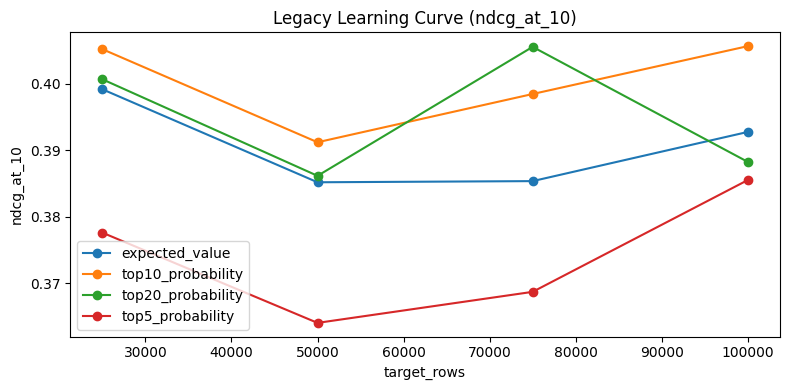

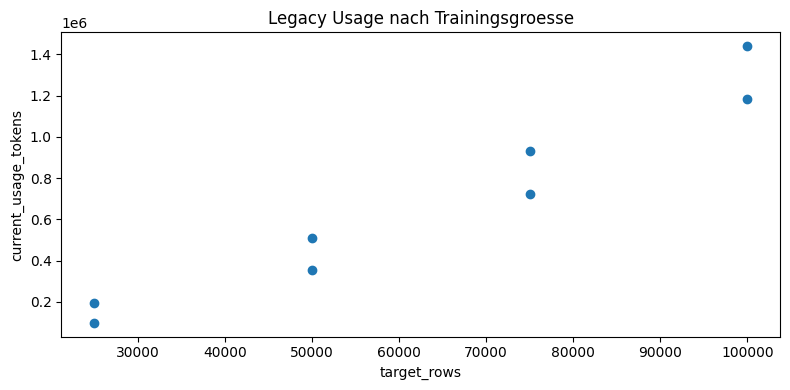

In [6]:
try:
    import matplotlib.pyplot as plt
except Exception as exc:
    plt = None
    warnings.warn(f"matplotlib nicht verfuegbar: {exc}")

if plt is not None and not classifier_summary.empty:
    metric = "roc_auc" if "roc_auc" in classifier_summary.columns else "ndcg_at_10"
    fig, ax = plt.subplots(figsize=(8, 4))
    for score_name, part in classifier_summary.groupby("score_name") if "score_name" in classifier_summary.columns else [("classifier", classifier_summary)]:
        part = part.sort_values("target_rows")
        ax.plot(part["target_rows"], part[metric], marker="o", label=str(score_name))
    ax.set_title(f"Legacy Learning Curve ({metric})")
    ax.set_xlabel("target_rows")
    ax.set_ylabel(metric)
    ax.legend(loc="best")
    fig.tight_layout()
    fig.savefig(RESULT_DIR / "legacy_learning_curve_roc_auc.png", dpi=160)
    plt.show()

if plt is not None and not usage_summary.empty and {"target_rows", "current_usage_tokens"}.issubset(usage_summary.columns):
    usage_plot = usage_summary[usage_summary.get("checkpoint", "") == "after_predict"].copy()
    if usage_plot.empty:
        usage_plot = usage_summary.copy()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(usage_plot["target_rows"], usage_plot["current_usage_tokens"])
    ax.set_title("Legacy Usage nach Trainingsgroesse")
    ax.set_xlabel("target_rows")
    ax.set_ylabel("current_usage_tokens")
    fig.tight_layout()
    fig.savefig(RESULT_DIR / "legacy_learning_curve_usage.png", dpi=160)
    plt.show()


## Ergebnisrolle

Diese Analyse ist nur Kontext. Die neuen Hyperparameter werden in `12-02` mit den aktuellen `data/model_data`-Splits und `Top10`-`roc_auc` validiert.
